# Imports and Configuration

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import cv2 
import pywt # For Wavelet Transform
import timm # For the ViT backbone
import matplotlib.pyplot as plt

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters aligned with Battocchio et al. and Corvi et al.
NUM_FRAMES = 8       # Temporal batch size
IMG_SIZE = 224       # Standard ViT input size
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

Using device: cuda


# Wavelet Augmentation Function


In [ ]:
def wavelet_blend(fake_frame, real_frame):
    """
    Applies Haar Wavelet decomposition and replaces the low-frequency 
    and H/V high-frequency components of 'fake_frame' with those from 'real_frame'.
    Keeps only the Diagonal details (cD) of the fake frame.
    """
    # Make sure tensors are on CPU and convert them to numpy
    # [C, H, W] -> [H, W, C]
    fake_np = fake_frame.detach().cpu().numpy().transpose(1, 2, 0) 
    real_np = real_frame.detach().cpu().numpy().transpose(1, 2, 0)
    
    aug_frame = np.zeros_like(fake_np)
    
    # Iterate over channels (RGB)
    for ch in range(3): 
        # 1-level decomposition (Haar)
        coeffs_fake = pywt.dwt2(fake_np[:,:,ch], 'haar')
        coeffs_real = pywt.dwt2(real_np[:,:,ch], 'haar')
        
        # cA = Approximation (Low frequencies)
        # cH = Horizontal details
        # cV = Vertical details
        # cD = Diagonal details (the ones we want to keep from the Fake!)
        cA_fake, (cH_fake, cV_fake, cD_fake) = coeffs_fake
        cA_real, (cH_real, cV_real, cD_real) = coeffs_real
        
        # MIXING STRATEGY:
        # Keep cD (Diagonal) from the FAKE (contains typical checkerboard artifacts)
        # Replace everything else with the REAL (removes semantic bias)
        new_coeffs = (cA_real, (cH_real, cV_real, cD_fake)) 
        
        # Reconstruction
        rec = pywt.idwt2(new_coeffs, 'haar')
        
        # Handle odd dimensions (idwt2 may be off by 1 pixel if input size is odd)
        # Coerce the shape to match the input
        h, w = fake_np.shape[:2]
        aug_frame[:,:,ch] = rec[:h, :w]
        
    # Safety clip: Bring values back to the [0, 1] range
    aug_frame = np.clip(aug_frame, 0.0, 1.0)
        
    # Return float32 tensor [C, H, W]
    return torch.from_numpy(aug_frame.transpose(2, 0, 1)).float()


In [20]:
# Forensic-Oriented Augmentation (from "Seeing What Matters")
import io
from PIL import Image

class ForensicAugmentation:
    """
    Implements the 5 forensic augmentations proposed in the paper
    to improve detector robustness against post-processing
    """
    def __init__(self):
        self.jpeg_qualities = [70, 75, 80, 85, 90, 95]
        self.blur_kernels = [(3,3), (5,5), (7,7)]
        self.noise_levels = [0.01, 0.02, 0.03, 0.05]
        self.resize_factors = [0.7, 0.8, 0.9, 1.1, 1.2]
        
    def jpeg_compression(self, frame):
        """Simulate JPEG compression with random quality"""
        quality = int(np.random.choice(self.jpeg_qualities))  
        # Convert tensor [C,H,W] to numpy [H,W,C]
        frame_np = (frame.cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
        
        # Simulate JPEG encode/decode
        pil_img = Image.fromarray(frame_np)
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer)
        
        # Return as tensor
        result = np.array(compressed).astype(np.float32) / 255.0
        return torch.from_numpy(result.transpose(2,0,1)).float()
    
    def gaussian_blur(self, frame):
        """Apply Gaussian blur"""
        kernel = int(np.random.choice([3, 5, 7])) 
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        blurred = cv2.GaussianBlur(frame_np, (kernel, kernel), 0)
        return torch.from_numpy(blurred.transpose(2,0,1)).float()
    
    def gaussian_noise(self, frame):
        """Add Gaussian noise"""
        noise_level = float(np.random.choice(self.noise_levels)) 
        noise = torch.randn_like(frame) * noise_level
        return torch.clamp(frame + noise, 0, 1)
    
    def resize_artifact(self, frame):
        """Simulate resizing with quality loss"""
        factor = float(np.random.choice(self.resize_factors)) 
        h, w = frame.shape[1], frame.shape[2]
        new_h, new_w = int(h * factor), int(w * factor)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        resized = cv2.resize(frame_np, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        restored = cv2.resize(resized, (w, h), interpolation=cv2.INTER_LINEAR)
        
        return torch.from_numpy(restored.transpose(2,0,1)).float()
    
    def color_jitter(self, frame):
        """Alter brightness/contrast/saturation"""
        brightness = np.random.uniform(0.8, 1.2)
        contrast = np.random.uniform(0.8, 1.2)
        saturation = np.random.uniform(0.8, 1.2)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        
        # Brightness
        frame_np = np.clip(frame_np * brightness, 0, 1)
        
        # Contrast
        mean = frame_np.mean()
        frame_np = np.clip((frame_np - mean) * contrast + mean, 0, 1)
        
        # Saturation (convert to HSV)
        hsv = cv2.cvtColor((frame_np * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,1] = np.clip(hsv[:,:,1] * saturation, 0, 255)
        rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
        
        return torch.from_numpy(rgb.transpose(2,0,1)).float()
    
    def apply_random_mix(self, frame, num_augs=2):
        """
        Apply 2-3 random augmentations in sequence
        This is the mixing strategy proposed in the paper
        """
        augs = [
            self.jpeg_compression,
            self.gaussian_blur,
            self.gaussian_noise,
            self.resize_artifact,
            self.color_jitter
        ]
        
        num_to_apply = int(np.random.randint(1, num_augs + 1))
        selected = np.random.choice(len(augs), num_to_apply, replace=False)
        
        for idx in selected:
            frame = augs[int(idx)](frame)  # FIX: Convert index to Python int
        
        return frame

# Initialize the object globally
forensic_aug = ForensicAugmentation()

def pyramid_noise_augmentation(frame, noise_levels=[0.01, 0.03, 0.05]):
    """
    Pyramid Noise Injection (from Battocchio et al.)
    Applies Gaussian noise with varying levels to simulate generative artifacts
    """
    noise_level = float(np.random.choice(noise_levels))
    noise = torch.randn_like(frame) * noise_level
    return torch.clamp(frame + noise, 0, 1)

# Custom Dataset Class

In [ ]:
class FakeVideoDataset(Dataset):
    def __init__(self, video_paths, labels, real_video_paths=None, transform=None, num_frames=8, is_train=True):
        """
        Args:
            video_paths: List of file paths to videos (mixed Real and Fake).
            labels: List of labels corresponding to video_paths (0 for Real, 1 for Fake).
            real_video_paths: List of ONLY real video paths. Needed for Wavelet Augmentation.
            transform: PyTorch transforms.
            num_frames: Number of frames to sample per video.
            is_train: Boolean to enable augmentation logic.
        """
        self.video_paths = video_paths
        self.labels = labels
        self.real_video_paths = real_video_paths if real_video_paths is not None else []
        self.transform = transform
        self.num_frames = num_frames
        self.is_train = is_train
        
        # Multi-scale temporal configurations (from Battocchio et al.)
        self.temporal_configs = [
            {'num_frames': 4, 'name': 'sparse'},      # Long-range dependencies
            {'num_frames': 8, 'name': 'uniform'},     # Standard
            {'num_frames': 16, 'name': 'dense'}       # Fast motions
        ]

    def load_video_frames(self, path, num_frames=None):
        """
        Loads uniformly sampled frames from the video.
        Supports multi-scale temporal sampling.
        Returns: [Frames, Channels, Height, Width]
        """
        if num_frames is None:
            num_frames = self.num_frames
            
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            print(f"Warning: Could not open {path}")
            return torch.zeros(num_frames, 3, 224, 224)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            cap.release()
            return torch.zeros(num_frames, 3, 224, 224)

        # Uniform sampling
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                frame = np.zeros((224, 224, 3), dtype=np.uint8) if not frames else frames[-1]
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (224, 224))
            
            frames.append(frame)
        cap.release()

        buffer = np.stack(frames)
        video_tensor = torch.from_numpy(buffer).float().permute(0, 3, 1, 2) / 255.0
        
        return video_tensor

    def get_reference_real_video(self, num_frames):
        """Selects a random real video from the pool for augmentation"""
        if not self.real_video_paths:
            return None
        rand_idx = np.random.randint(0, len(self.real_video_paths))
        return self.load_video_frames(self.real_video_paths[rand_idx], num_frames)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]
        
        # Multi-scale temporal sampling during training
        if self.is_train and np.random.rand() < 0.3:  # 30% of the time use an alternative config
            config = np.random.choice(self.temporal_configs)
            num_frames = config['num_frames']
        else:
            num_frames = self.num_frames
        
        video = self.load_video_frames(path, num_frames)
        
        # Padding/trimming to keep num_frames consistent
        if video.shape[0] != self.num_frames:
            if video.shape[0] < self.num_frames:
                # Padding: repeat the last frame
                padding = self.num_frames - video.shape[0]
                video = torch.cat([video, video[-1:].repeat(padding, 1, 1, 1)], dim=0)
            else:
                # Trimming: keep only the first num_frames
                video = video[:self.num_frames]

        # === AUGMENTATION PIPELINE ===
        if self.is_train:
            aug_frames = []
            
            for i in range(self.num_frames):
                frame = video[i]
                
                # Wavelet Augmentation (FAKE only)
                if label == 1 and len(self.real_video_paths) > 0 and np.random.rand() < 0.5:
                    ref_video = self.get_reference_real_video(self.num_frames)
                    if ref_video is not None:
                        frame = wavelet_blend(frame, ref_video[i])
                
                # Forensic Augmentation Mix (applied to ALL during training)
                if np.random.rand() < 0.6:  # 60% probability
                    frame = forensic_aug.apply_random_mix(frame, num_augs=2)
                
                # Pyramid Noise (from Battocchio et al. - applied randomly)
                if np.random.rand() < 0.3:  # 30% probability
                    frame = pyramid_noise_augmentation(frame)
                
                aug_frames.append(frame)
            
            video = torch.stack(aug_frames)

        # Standard Transforms (ImageNet normalization)
        if self.transform:
            video = torch.stack([self.transform(f) for f in video])
            
        return video, label

    def __len__(self):
        return len(self.video_paths)


# Advanced Architecture Components

In [22]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module (from Battocchio et al.)
    Allows the model to focus on the most informative regions
    """
    def __init__(self, dim=768, reduction=4):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // reduction),
            nn.ReLU(),
            nn.Linear(dim // reduction, dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: [B, F, 768]
        weights = self.attention(x)
        return x * weights

class TemporalConsistency(nn.Module):
    """
    Temporal Consistency Checker
    Verifies temporal coherence between frames (fakes often show inconsistencies)
    """
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    
    def forward(self, temporal_features):
        # temporal_features: [B, F, 768]
        lstm_out, (h_n, _) = self.lstm(temporal_features)
        # Use the last hidden state (bidirectional concatenation)
        consistency_score = self.fc(torch.cat([h_n[0], h_n[1]], dim=1))
        return consistency_score

def frequency_domain_loss(features1, features2):
    """
    FFT-based Loss (from "Seeing What Matters")
    Compares frequency spectra to capture imperceptible artifacts
    """
    # Reshape if necessary: [B, 768] -> [B, 1, 768]
    if len(features1.shape) == 2:
        features1 = features1.unsqueeze(1)
        features2 = features2.unsqueeze(1)
    
    fft1 = torch.fft.rfft(features1, dim=-1)
    fft2 = torch.fft.rfft(features2, dim=-1)
    
    # Compare spectral magnitudes
    mag1 = torch.abs(fft1)
    mag2 = torch.abs(fft2)
    
    return nn.functional.mse_loss(mag1, mag2)

# 3D-ViT Model Architecture


In [ ]:
class Detector3DViT(nn.Module):
    def __init__(self, pretrained=True, use_advanced_features=True):
        super(Detector3DViT, self).__init__()
        
        self.use_advanced_features = use_advanced_features
        
        # Load ViT backbone
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=pretrained)
        
        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Spatial Attention Module
        if use_advanced_features:
            self.spatial_attn = SpatialAttention(dim=768, reduction=4)
            self.temporal_checker = TemporalConsistency(input_dim=768, hidden_dim=256)
        
        # Classifier Head (Enhanced)
        self.head = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)  # Binary output
        )
        
    def forward(self, x, return_features=False):
        # Input: [B, F, C, H, W] -> [B, 8, 3, 224, 224]
        b, f, c, h, w = x.shape
        
        # Merge Batch and Frames
        x = x.view(b * f, c, h, w) 
        
        # Feature extraction
        features = self.backbone.forward_features(x)  # [B*F, Tokens, 768]
        
        # CLS token extraction
        cls_token = features[:, 0]  # [B*F, 768]
        
        # Restore temporal dimension
        cls_token = cls_token.view(b, f, -1)  # [B, F, 768]
        
        # Apply Spatial Attention
        if self.use_advanced_features:
            cls_token = self.spatial_attn(cls_token)
        
        # Temporal Pooling (mean across frames)
        video_features = torch.mean(cls_token, dim=1)  # [B, 768]
        
        # Final classification
        logits = self.head(video_features)
        
        # Also compute temporal consistency
        if self.use_advanced_features and self.training:
            temp_consistency = self.temporal_checker(cls_token)
            if return_features:
                return logits, temp_consistency, video_features
            return logits, temp_consistency
        
        if return_features:
            return logits, video_features
        return logits


# Training Setup and Loop


In [24]:
def train_one_epoch(model, loader, criterion, optimizer, use_advanced_loss=True):
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_temp_loss = 0.0
    total_freq_loss = 0.0
    correct = 0
    total = 0
    
    for i, (videos, labels) in enumerate(loader):
        videos = videos.to(device)
        labels = labels.to(device).float().unsqueeze(1)  # [B, 1]
        
        optimizer.zero_grad()
        
        # Forward pass
        if use_advanced_loss:
            outputs, temp_consistency, features = model(videos, return_features=True)
            
            # Loss 1: Binary Classification
            cls_loss = criterion(outputs, labels)
            
            # Loss 2: Temporal Consistency (fakes should have lower scores)
            temp_loss = nn.functional.mse_loss(temp_consistency, labels) * 0.3
            
            # Loss 3: Frequency Domain Loss (compare with reference)
            # Create a target reference (mean of real features in the batch)
            real_mask = (labels == 0).squeeze()
            if real_mask.sum() > 0:
                real_features_mean = features[real_mask].mean(dim=0, keepdim=True)
                freq_loss = frequency_domain_loss(
                    features, real_features_mean.expand_as(features)
                ) * 0.1
            else:
                freq_loss = torch.tensor(0.0).to(device)
            
            # Combine losses
            loss = cls_loss + temp_loss + freq_loss
            
            total_cls_loss += cls_loss.item()
            total_temp_loss += temp_loss.item()
            total_freq_loss += freq_loss.item()
        else:
            outputs = model(videos)
            loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if i % 10 == 0:
            if use_advanced_loss:
                print(f"   Step {i}/{len(loader)} | Total: {loss.item():.4f} "
                      f"(Cls: {cls_loss.item():.3f}, Temp: {temp_loss.item():.3f}, Freq: {freq_loss.item():.4f})")
            else:
                print(f"   Step {i}/{len(loader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    if use_advanced_loss:
        print(f"   Avg Losses - Cls: {total_cls_loss/len(loader):.4f}, "
              f"Temp: {total_temp_loss/len(loader):.4f}, Freq: {total_freq_loss/len(loader):.4f}")
    
    return avg_loss, accuracy

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            # During validation we only use the main output
            if isinstance(model(videos), tuple):
                outputs = model(videos)[0]  # Take only logits
            else:
                outputs = model(videos)
                
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total


# Training configuration and execution 

Scanning folders...
Found 450 Real and 450 Fake videos.
Dataset split: 720 Train, 180 Validation

=== Initializing Advanced 3D-ViT with Multi-Task Learning ===
Features enabled:
  - Wavelet Frequency Augmentation
  - Forensic Augmentation Mix (JPEG, Blur, Noise, Resize, Color)
  - Pyramid Noise Injection
  - Multi-Scale Temporal Sampling (4/8/16 frames)
  - Spatial Attention Module
  - Temporal Consistency Checker
  - Frequency Domain Loss



c:\Users\aless\Desktop\Trends\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...

Epoch 1/15 | LR: 0.000100
   Step 0/90 | Total: 10.4759 (Cls: 0.687, Temp: 0.159, Freq: 9.6298)
   Step 10/90 | Total: 7.8771 (Cls: 0.676, Temp: 0.193, Freq: 7.0082)
   Step 20/90 | Total: 8.2651 (Cls: 0.665, Temp: 0.144, Freq: 7.4561)
   Step 30/90 | Total: 8.8166 (Cls: 0.687, Temp: 0.224, Freq: 7.9053)
   Step 40/90 | Total: 8.9076 (Cls: 0.654, Temp: 0.135, Freq: 8.1178)
   Step 50/90 | Total: 7.7625 (Cls: 0.702, Temp: 0.247, Freq: 6.8141)
   Step 60/90 | Total: 6.8701 (Cls: 0.688, Temp: 0.196, Freq: 5.9864)
   Step 70/90 | Total: 11.2795 (Cls: 0.640, Temp: 0.149, Freq: 10.4902)
   Step 80/90 | Total: 7.0535 (Cls: 0.708, Temp: 0.225, Freq: 6.1206)
   Avg Losses - Cls: 0.6684, Temp: 0.1680, Freq: 8.5466

EPOCH SUMMARY:
   Train Loss: 9.3831 | Train Acc: 52.22%
   Val Loss:   0.6652 | Val Acc:   50.00%
   New best model saved (Val Acc: 50.00%)

Epoch 2/15 | LR: 0.000100
   Step 0/90 | Total: 9.1990 (Cls: 0.652, Temp: 0.158, Freq: 8.3891)
   Step 10/90 | Total: 12.

FileNotFoundError: [Errno 2] No such file or directory: 'results/training_results.png'

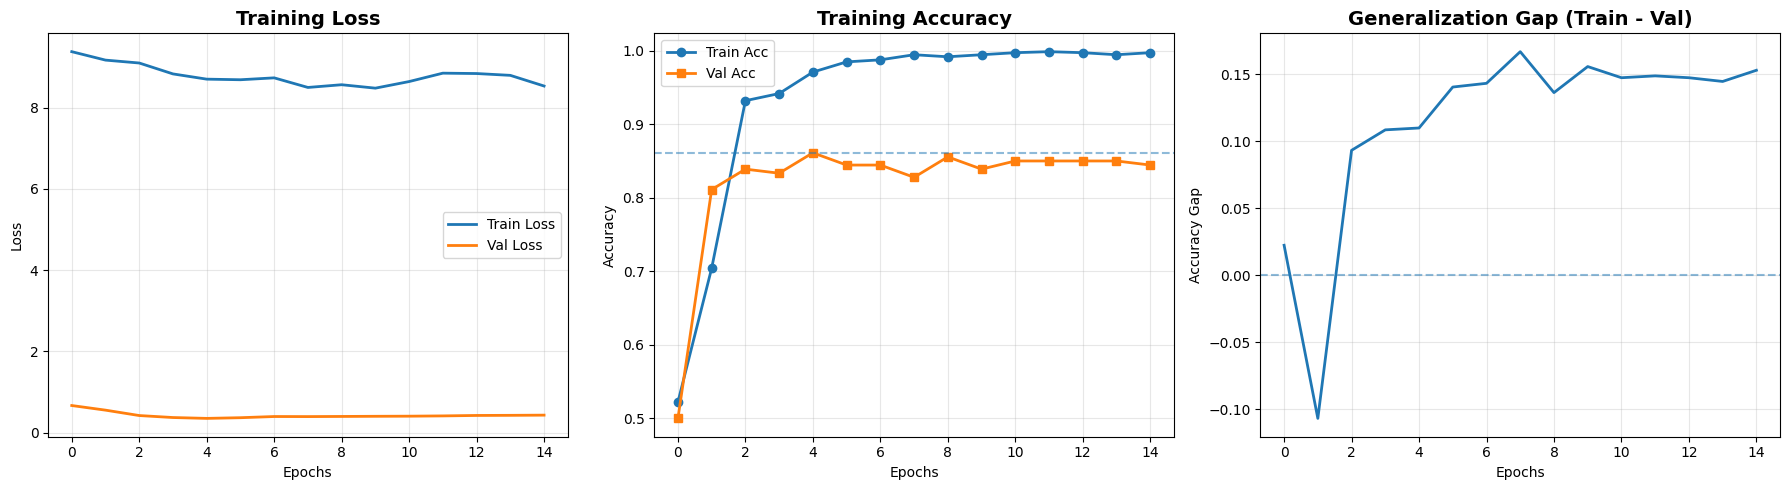

In [ ]:
import glob
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load files
print("Scanning folders...")
real_paths = sorted(glob.glob("datasets/real/*.mp4"))
fake_paths = sorted(glob.glob("datasets/fake_pyramid/*.mp4"))

if len(real_paths) == 0 or len(fake_paths) == 0:
    print("ERROR: No videos found!")
    print(f"   Real found: {len(real_paths)}, Fake found: {len(fake_paths)}")
    raise ValueError("Check the folder paths!")
else:
    print(f"Found {len(real_paths)} Real and {len(fake_paths)} Fake videos.")

# 2. Balancing
min_len = min(len(real_paths), len(fake_paths))
real_paths = real_paths[:min_len]
fake_paths = fake_paths[:min_len]

all_paths = real_paths + fake_paths
all_labels = [0] * len(real_paths) + [1] * len(fake_paths)

# 3. Train/Val split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Dataset split: {len(train_paths)} Train, {len(val_paths)} Validation")

# 4. Dataset initialization (with all augmentations)
train_dataset = FakeVideoDataset(
    video_paths=train_paths, 
    labels=train_labels, 
    real_video_paths=real_paths,
    num_frames=NUM_FRAMES,
    is_train=True 
)

val_dataset = FakeVideoDataset(
    video_paths=val_paths, 
    labels=val_labels, 
    real_video_paths=None,
    num_frames=NUM_FRAMES,
    is_train=False
)

# 5. Dataloaders
BATCH_SIZE = 8 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 6. Model setup
print("\n=== Initializing Advanced 3D-ViT with Multi-Task Learning ===")
print("Features enabled:")
print("  - Wavelet Frequency Augmentation")
print("  - Forensic Augmentation Mix (JPEG, Blur, Noise, Resize, Color)")
print("  - Pyramid Noise Injection")
print("  - Multi-Scale Temporal Sampling (4/8/16 frames)")
print("  - Spatial Attention Module")
print("  - Temporal Consistency Checker")
print("  - Frequency Domain Loss")
print()

model = Detector3DViT(use_advanced_features=True).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.head.parameters(), lr=1e-4)

# Learning rate scheduler for better convergence
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

# Lists for plots
train_losses, val_losses = [], []
train_accs, val_accs = [], []

NUM_EPOCHS = 10

best_val_acc = 0.0

# --- TRAINING LOOP ---
print("Starting training...")
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"{'='*60}")
    
    # Train
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, use_advanced_loss=True)
    
    # Validate
    v_loss, v_acc = validate(model, val_loader, criterion)
    
    # Learning rate scheduling
    scheduler.step(v_acc)
    
    # Store metrics
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)
    
    print(f"\nEPOCH SUMMARY:")
    print(f"   Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
    print(f"   Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
    
    # Save best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': v_acc,
            'train_acc': t_acc
        }, "models/best_model_3dvit.pth")
        print(f"   New best model saved (Val Acc: {v_acc*100:.2f}%)")

print("\n" + "="*60)
print(f"Training completed! Best Val Accuracy: {best_val_acc*100:.2f}%")
print("="*60)

# 7. Enhanced plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Acc', linewidth=2, marker='o')
axes[1].plot(val_accs, label='Val Acc', linewidth=2, marker='s')
axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=best_val_acc, linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.3f}')

# Overfitting analysis
axes[2].plot(np.array(train_accs) - np.array(val_accs), linewidth=2)
axes[2].set_title('Generalization Gap (Train - Val)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Accuracy Gap')
axes[2].axhline(y=0, linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_results.png', dpi=150)
plt.show()

print("\nTraining plots saved to 'results/training_results.png'")
